# EDA — TY Futures Minute Bars

Exploratory analysis:
1. Class imbalance — bars closing above vs below open
2. Average intrabar move (up vs down)
3. Price return over the full dataset period
4. Are flat bars (Close == Open) market downtime?

In [1]:
import sys
from pathlib import Path

# Locate project root regardless of where Jupyter was launched from
_root = Path.cwd()
while not (_root / 'src').exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

DATA_PATH = _root / 'data' / 'raw' / 'data.csv'

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from src.load import load_raw

sns.set_theme(style='darkgrid')
plt.rcParams.update({'figure.dpi': 110})

df = load_raw(DATA_PATH)
print(df.shape)
df.head(3)

Loaded 551,521 rows from /Volumes/SandiskSSD/research/futures-prediction/data/raw/data.csv
(551521, 14)


,Date,Time,Date and Time,Symbol,Open,High,Low,Close,VWAP,Volume,Up Ticks,Down Ticks,Same Ticks,Tick Count
0,1/3/2023,4:01:00,2023-01-03 04:01:00,TYH23,113.015625,113.015625,113.0,113.015625,113.01440,256,4,4,14,22
1,1/3/2023,4:02:00,2023-01-03 04:02:00,TYH23,113.015625,113.031250,113.0,113.000000,113.01540,846,6,7,35,48
2,1/3/2023,4:03:00,2023-01-03 04:03:00,TYH23,113.015625,113.031250,113.0,113.015625,113.01608,1175,5,4,141,150


## 1. Class imbalance — Close > Open vs Close ≤ Open

,Count,Pct %
direction,,
Down / Flat (Close <= Open),405567,73.54
Up (Close > Open),145954,26.46


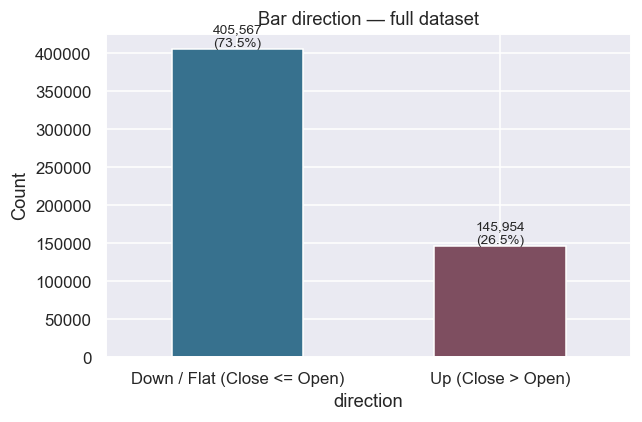

In [2]:
df['direction'] = (df['Close'] > df['Open']).map(
    {True: 'Up (Close > Open)', False: 'Down / Flat (Close <= Open)'}
)

counts = df['direction'].value_counts()
pcts   = df['direction'].value_counts(normalize=True) * 100
display(counts.rename('Count').to_frame().join(pcts.rename('Pct %').round(2)))

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot.bar(ax=ax, color=['#37718E', '#7E4E60'], edgecolor='white', width=0.5)
ax.set_title('Bar direction — full dataset', fontsize=12)
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}\n({p.get_height()/len(df)*100:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=9,
    )
plt.tight_layout()
plt.show()

## 2. Average points gained / lost per bar

,Count,Avg move (pts),Median (pts),Max move (pts)
Up bars,145954,0.0197,0.0156,1.0625
Down bars,142574,-0.0198,-0.0156,-0.7656
Flat bars,262993,0.0000,0.0000,0.0000


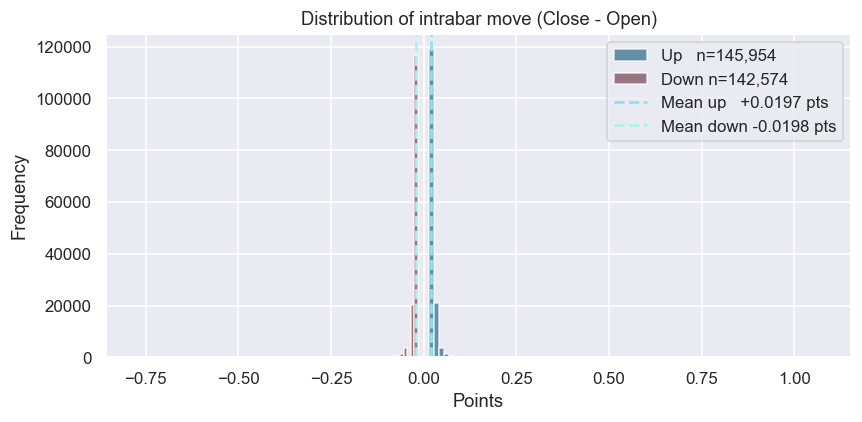

In [3]:
df['move'] = df['Close'] - df['Open']

up   = df.loc[df['move'] > 0,  'move']
down = df.loc[df['move'] < 0,  'move']
flat = df.loc[df['move'] == 0, 'move']

move_summary = pd.DataFrame(
    {
        'Count':          [len(up),      len(down),     len(flat)],
        'Avg move (pts)': [up.mean(),    down.mean(),   0.0],
        'Median (pts)':   [up.median(),  down.median(), 0.0],
        'Max move (pts)': [up.max(),     down.min(),    0.0],
    },
    index=['Up bars', 'Down bars', 'Flat bars'],
).round(4)
display(move_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(up,   bins=80, alpha=0.75, color='#37718E', label=f'Up   n={len(up):,}')
ax.hist(down, bins=80, alpha=0.75, color='#7E4E60', label=f'Down n={len(down):,}')
ax.axvline(up.mean(),   color='#8EE3EF', linewidth=1.8, linestyle='--',
           label=f'Mean up   {up.mean():+.4f} pts')
ax.axvline(down.mean(), color='#AEF3E7', linewidth=1.8, linestyle='--',
           label=f'Mean down {down.mean():+.4f} pts')
ax.set_title('Distribution of intrabar move (Close - Open)')
ax.set_xlabel('Points')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Return over the full dataset period

Period : 2023-01-03 04:01:00  ->  2026-01-09 16:00:00
Start  : 113.0156
End    : 112.2344
Return : -0.7812 pts  (-0.69%)


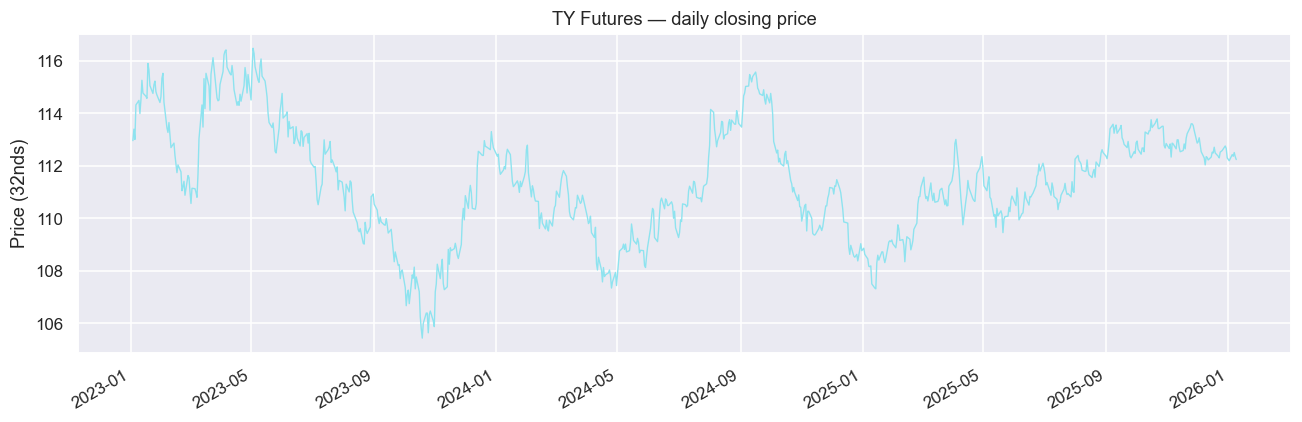

In [4]:
df_sorted = df.sort_values('Date and Time')

p_start   = df_sorted['Close'].iloc[0]
p_end     = df_sorted['Close'].iloc[-1]
t_start   = df_sorted['Date and Time'].iloc[0]
t_end     = df_sorted['Date and Time'].iloc[-1]
total_pts = p_end - p_start
total_pct = total_pts / p_start * 100

print(f'Period : {t_start}  ->  {t_end}')
print(f'Start  : {p_start:.4f}')
print(f'End    : {p_end:.4f}')
print(f'Return : {total_pts:+.4f} pts  ({total_pct:+.2f}%)')

daily = (
    df_sorted.set_index('Date and Time')['Close']
    .resample('D')
    .last()
    .dropna()
)

fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax, color='#8EE3EF', linewidth=0.9)
ax.set_title('TY Futures — daily closing price')
ax.set_ylabel('Price (32nds)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 4. Are flat bars (Close == Open) market downtime?

Hypothesis: flat bars are just market downtime, identifiable by `Volume == 0`. We test this directly and compare the volume distribution of flat vs non-flat bars.

Flat bars (Close == Open): 262,993  (47.69% of 551,521)
Dataset Volume  — min: 1   zero-volume rows: 0
Flat bars with Volume == 0 (downtime hypothesis): 0
Flat bars at minimum Volume == 1 (thinnest market): 3,203


,Flat (Close==Open),Non-flat (Close!=Open)
count,262993.0,288528.0
mean,1428.6,2452.4
std,2240.2,3940.1
min,1.0,2.0
25%,123.0,419.0
50%,665.0,1461.0
75%,1943.0,3167.0
max,151166.0,239310.0


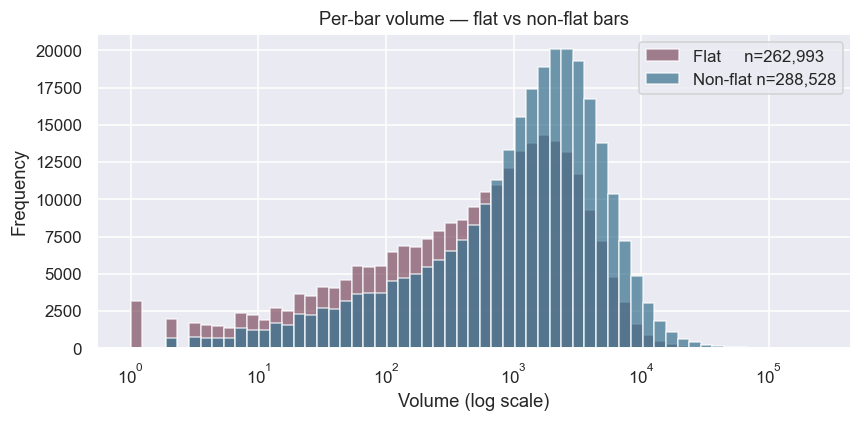

In [5]:
import numpy as np

flat = df['Close'] == df['Open']
n_flat = int(flat.sum())

print(f"Flat bars (Close == Open): {n_flat:,}  ({n_flat / len(df) * 100:.2f}% of {len(df):,})")
print(f"Dataset Volume  — min: {df['Volume'].min():,}   zero-volume rows: {int((df['Volume'] == 0).sum()):,}")
print(f"Flat bars with Volume == 0 (downtime hypothesis): {int((df.loc[flat, 'Volume'] == 0).sum()):,}")
print(f"Flat bars at minimum Volume == 1 (thinnest market): {int((df.loc[flat, 'Volume'] == 1).sum()):,}")

# Volume distribution: flat vs non-flat bars
vol_summary = pd.DataFrame({
    'Flat (Close==Open)':     df.loc[flat,  'Volume'].describe(),
    'Non-flat (Close!=Open)': df.loc[~flat, 'Volume'].describe(),
}).round(1)
display(vol_summary)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.logspace(0, np.log10(df['Volume'].max()), 60)
ax.hist(df.loc[flat,  'Volume'], bins=bins, alpha=0.7, color='#7E4E60',
        label=f'Flat     n={n_flat:,}')
ax.hist(df.loc[~flat, 'Volume'], bins=bins, alpha=0.7, color='#37718E',
        label=f'Non-flat n={len(df) - n_flat:,}')
ax.set_xscale('log')
ax.set_title('Per-bar volume — flat vs non-flat bars')
ax.set_xlabel('Volume (log scale)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusion.** The `Volume == 0` downtime hypothesis is **rejected** — the dataset has no zero-volume bars at all (min Volume = 1), so *none* of the flat bars are market downtime by that definition. Flat bars are genuine, actively-traded bars (median volume ≈ 665) where order flow netted out to `Close == Open` within the minute. They therefore can't be discarded as data gaps; that is why the no-flat experiments treat *removing* them as a **modelling choice**, not data cleaning.